In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from pathlib import Path

np.random.seed(42)

# Project folders
BASE_DIR = Path("/content/hybrid_neural_sindy")
DATA_DIR = BASE_DIR / "data"
FIGURES_DIR = BASE_DIR / "figures"
RESULTS_DIR = BASE_DIR / "results"

for folder in [DATA_DIR, FIGURES_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders created successfully:")
print("Base folder:", BASE_DIR)
print("Data folder:", DATA_DIR)
print("Figures folder:", FIGURES_DIR)
print("Results folder:", RESULTS_DIR)

Folders created successfully:
Base folder: /content/hybrid_neural_sindy
Data folder: /content/hybrid_neural_sindy/data
Figures folder: /content/hybrid_neural_sindy/figures
Results folder: /content/hybrid_neural_sindy/results


In [2]:
def van_der_pol(t, state, mu=2.0):
    """
    Van der Pol oscillator.

    state[0] = x
    state[1] = y

    dx/dt = y
    dy/dt = mu * (1 - x^2) * y - x
    """
    x, y = state

    dxdt = y
    dydt = mu * (1 - x**2) * y - x

    return [dxdt, dydt]

In [3]:
# Simulation settings
mu = 2.0
t_start = 0
t_end = 30
n_points = 3000

t_eval = np.linspace(t_start, t_end, n_points)

# Initial condition: [x0, y0]
initial_state = [2.0, 0.0]

solution = solve_ivp(
    fun=lambda t, state: van_der_pol(t, state, mu=mu),
    t_span=(t_start, t_end),
    y0=initial_state,
    t_eval=t_eval,
    method="RK45"
)

# Extract clean trajectory
t = solution.t
x_clean = solution.y[0]
y_clean = solution.y[1]

print("Simulation complete.")
print("t shape:", t.shape)
print("x_clean shape:", x_clean.shape)
print("y_clean shape:", y_clean.shape)

Simulation complete.
t shape: (3000,)
x_clean shape: (3000,)
y_clean shape: (3000,)


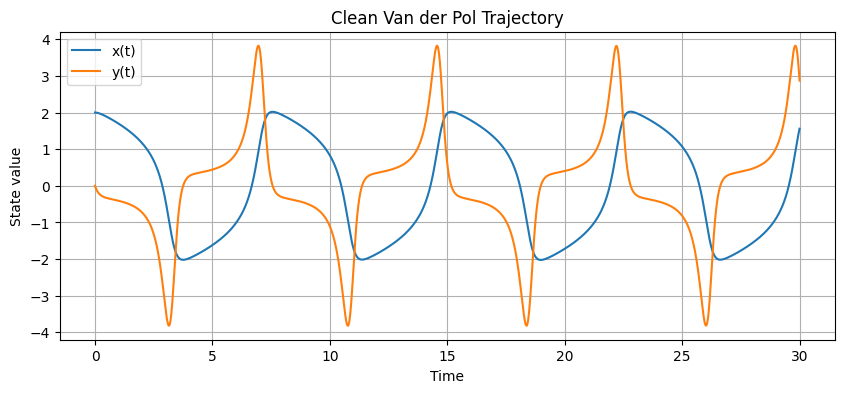

In [4]:
plt.figure(figsize=(10, 4))

plt.plot(t, x_clean, label="x(t)")
plt.plot(t, y_clean, label="y(t)")

plt.xlabel("Time")
plt.ylabel("State value")
plt.title("Clean Van der Pol Trajectory")
plt.legend()
plt.grid(True)

plt.savefig(FIGURES_DIR / "vdp_clean_time_series.png", dpi=300, bbox_inches="tight")
plt.show()

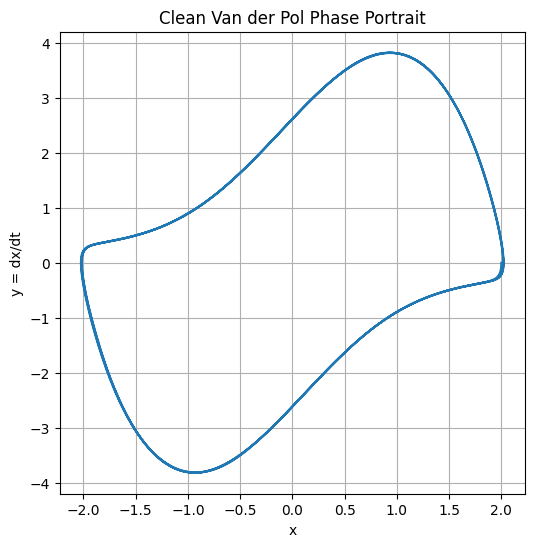

In [5]:
plt.figure(figsize=(6, 6))

plt.plot(x_clean, y_clean)

plt.xlabel("x")
plt.ylabel("y = dx/dt")
plt.title("Clean Van der Pol Phase Portrait")
plt.grid(True)

plt.savefig(FIGURES_DIR / "vdp_clean_phase_portrait.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
def add_gaussian_noise(data, noise_std=0.05, seed=42):
    """
    Add Gaussian measurement noise to trajectory data.

    data shape: (n_points, n_variables)
    """
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=noise_std, size=data.shape)
    return data + noise


# Combine x and y into one trajectory matrix
clean_trajectory = np.column_stack([x_clean, y_clean])

# Add noise
noise_std = 0.15
noisy_trajectory = add_gaussian_noise(clean_trajectory, noise_std=noise_std, seed=42)

x_noisy = noisy_trajectory[:, 0]
y_noisy = noisy_trajectory[:, 1]

print("Noise added.")
print("clean_trajectory shape:", clean_trajectory.shape)
print("noisy_trajectory shape:", noisy_trajectory.shape)

Noise added.
clean_trajectory shape: (3000, 2)
noisy_trajectory shape: (3000, 2)


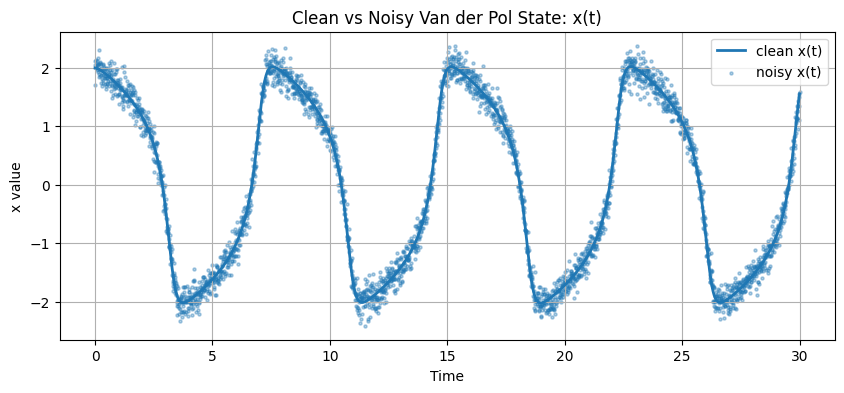

In [7]:
plt.figure(figsize=(10, 4))

plt.plot(t, x_clean, label="clean x(t)", linewidth=2)
plt.scatter(t, x_noisy, label="noisy x(t)", s=5, alpha=0.35)

plt.xlabel("Time")
plt.ylabel("x value")
plt.title("Clean vs Noisy Van der Pol State: x(t)")
plt.legend()
plt.grid(True)

plt.savefig(FIGURES_DIR / "vdp_clean_vs_noisy_x.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
vdp_df = pd.DataFrame({
    "t": t,
    "x_clean": x_clean,
    "y_clean": y_clean,
    "x_noisy": x_noisy,
    "y_noisy": y_noisy
})

csv_path = DATA_DIR / "vdp_clean_noisy_trajectory.csv"
vdp_df.to_csv(csv_path, index=False)

print("Saved dataset to:")
print(csv_path)

vdp_df.head()

Saved dataset to:
/content/hybrid_neural_sindy/data/vdp_clean_noisy_trajectory.csv


,t,x_clean,y_clean,x_noisy,y_noisy
0,0.000000,2.000000,0.000000,2.045708,-0.155998
1,0.010003,1.999902,-0.019418,2.112470,0.121667
2,0.020007,1.999615,-0.037703,1.706960,-0.233030
3,0.030010,1.999151,-0.054921,2.018327,-0.102358
4,0.040013,1.998520,-0.071135,1.996000,-0.199091
